<a href="https://colab.research.google.com/github/algroznykh/notebooks/blob/master/1d_dilation_nca_simple_arithmetic_positional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# solving toy arithmetic problems (+- up to 99 in base10) with 1d dilation NCA (1:0:1 | 1:2:1 connections)
!nvidia-smi

Wed Dec 17 21:11:03 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   75C    P0             34W /   72W |     315MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
from IPython.display import Image, HTML, clear_output


import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random

In [35]:
# Vocabulary: 0-9, +, -, =, and '.' (padding/empty)
VOCAB = "0123456789 +-=."
VOCAB_SIZE = len(VOCAB)
PAD_TOKEN = VOCAB.index('.')

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
CHN = VOCAB_SIZE * 2
TRAIN_STEPS = 2000
NCA_STEPS_MIN = CHN*2
NCA_STEPS_MAX = CHN*4


def encode_str(s, length=None):
    """One-hot encode string to (Channels, Length)"""
    if length is None:
      length = len(s)
    indices = [VOCAB.index(c) for c in s]

    indices += [PAD_TOKEN] * (length - len(indices))
    indices = torch.tensor(indices, dtype=torch.long)
    return F.one_hot(indices, num_classes=VOCAB_SIZE).permute(1, 0).float()

def decode_output(tensor):
    """Convert (Channels, Length) tensor back to string"""
    indices = tensor.argmax(dim=0).cpu().numpy()
    return "".join([VOCAB[i] for i in indices])

def generate_batch(batch_size):
    inputs = []
    targets = []

    SEQ_LEN = 9

    for _ in range(batch_size):
        a = random.randint(0, 99)
        b = random.randint(0, 99)
        op = random.choice(['+', '-'])

        # Ensure non-negative results for simplicity in this demo
        if op == '-' and b > a: a, b = b, a

        res = a + b if op == '+' else a - b

        # Format: "12+5=" -> "12+5=17"
        query_str = f"{a}{op}{b}="
        target_str = f"{a}{op}{b}={res}"

        x = encode_str(query_str, length=SEQ_LEN)
        y = encode_str(target_str, length=SEQ_LEN)

        state = torch.zeros(CHN, SEQ_LEN)
        state[:VOCAB_SIZE, :] = x

        inputs.append(state)
        targets.append(y)

    return torch.stack(inputs).to(DEVICE), torch.stack(targets).to(DEVICE)


class dilationNCA(nn.Module):
    def __init__(self, n_channels, hidden_dim):
        super().__init__()
        self.n_channels = n_channels

        self.perceive = nn.Conv1d(
            n_channels,
            hidden_dim // 2,
            kernel_size=3,
            padding=1,
            stride=1,
            padding_mode='circular'
        )

        self.p2 = nn.Conv1d(
            n_channels,
            hidden_dim // 2,
            kernel_size=3,
            padding=3,
            stride=1,
            dilation=3,
            padding_mode='circular'
        )

        self.nin1 = nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)
        self.nin2 = nn.Conv1d(hidden_dim, n_channels, kernel_size=1)

        nn.init.zeros_(self.nin2.weight)
        nn.init.zeros_(self.nin2.bias)

    def forward(self, x, steps, update_rate=.5):

        for step in range(steps):
            p = self.perceive(x)
            p2 = self.p2(x)
            perception = torch.cat((p, p2), 1)

            dx = F.relu(self.nin1(perception))
            dx = self.nin2(dx)

            mask = (torch.rand(x.shape[0], 1, x.shape[2], device=x.device) < update_rate).float()

            x = x + dx * mask

        return x


model = dilationNCA(n_channels=CHN, hidden_dim=128).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

criterion = nn.CrossEntropyLoss()

loss_log = []


In [52]:
for i in range(TRAIN_STEPS):
    inputs, targets = generate_batch(BATCH_SIZE)

    steps = random.randint(NCA_STEPS_MIN, NCA_STEPS_MAX)

    final_state = model(inputs, steps)

    output_visible = final_state[:, :VOCAB_SIZE, :]

    loss = criterion(output_visible, targets.argmax(dim=1))

    loss_log.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if i % 10 == 0:
        idx = 0
        pred_str = decode_output(output_visible[idx])
        target_str = decode_output(targets[idx])

        input_vocab = inputs[idx, :VOCAB_SIZE, :]
        query_input = decode_output(input_vocab)

        print(f"Step {i:4d} ({len(loss_log)}) | Loss: {loss.item():.4f}")
        print(f"  Input : {query_input}")
        print(f"  Target: {target_str}")
        print(f"  Output: {pred_str}")
        print("-" * 30)
        clear_output(True)



KeyboardInterrupt: 

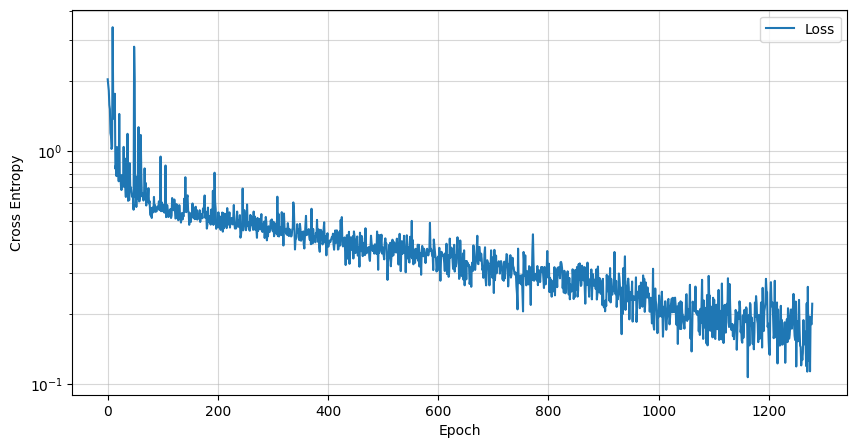

Input : 14+42=...
Result: 14+42=56.
Truth : 14+42=56.


In [55]:
# plot loss long and run one test

with torch.no_grad():
  plt.figure(figsize=(10, 5))
  plt.plot(loss_log, label='Loss')
  plt.yscale('log')
  plt.xlabel('Epoch')
  plt.ylabel('Cross Entropy')
  plt.grid(True, which="both", ls="-", alpha=0.5)
  plt.legend()
  plt.show()

test_input, test_target = generate_batch(1)

steps = random.randint(NCA_STEPS_MIN, NCA_STEPS_MAX)

final_state = model(test_input, steps=steps)

res = decode_output(final_state[0, :VOCAB_SIZE, :])
tgt = decode_output(test_target[0])
inp = decode_output(test_input[0, :VOCAB_SIZE, :])

print(f"Input : {inp}")
print(f"Result: {res}")
print(f"Truth : {tgt}")


In [53]:
history = []

test_input, test_target = generate_batch(1)
state = test_input


with torch.no_grad():
    for i in range(steps):
        current_frame = state[0].cpu().numpy()
        history.append(current_frame)

        state = model(state, 1)

    final_state = state
    res = decode_output(final_state[0, :VOCAB_SIZE, :])
    tgt = decode_output(test_target[0])
    inp = decode_output(test_input[0, :VOCAB_SIZE, :])

    print(f"Input : {inp}")
    print(f"Result: {res}")
    print(f"Truth : {tgt}")


fig, ax = plt.subplots(figsize=(10, 4))
plt.close() # Prevent double display in notebooks


img_plot = ax.imshow(history[0][:VOCAB_SIZE-1, :], cmap='gray', aspect='auto', vmin=-1.0, vmax=1.0, interpolation='nearest')

ax.set_title("NCA State")
ax.set_ylabel("State")
ax.set_xlabel("Position")

def softmax(x):
  return np.exp(x)/sum(np.exp(x))


def update_frame(frame_idx):
    data = history[frame_idx]
    data = softmax(data)
    data = data[:VOCAB_SIZE-1, :]
    img_plot.set_data(data)
    ax.set_title(f"Step: {frame_idx}")
    return [img_plot]

print("Rendering Video...")
ani = animation.FuncAnimation(fig, update_frame, frames=len(history), interval=50, blit=True)

ani.save('nca_state_visualization.mp4', writer='ffmpeg', fps=8)

display(HTML(ani.to_html5_video()))


Input : 97+65=...
Result: 97+65=162
Truth : 97+65=162
Rendering Video...
